In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import numpy as np
from PIL import Image
import random

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


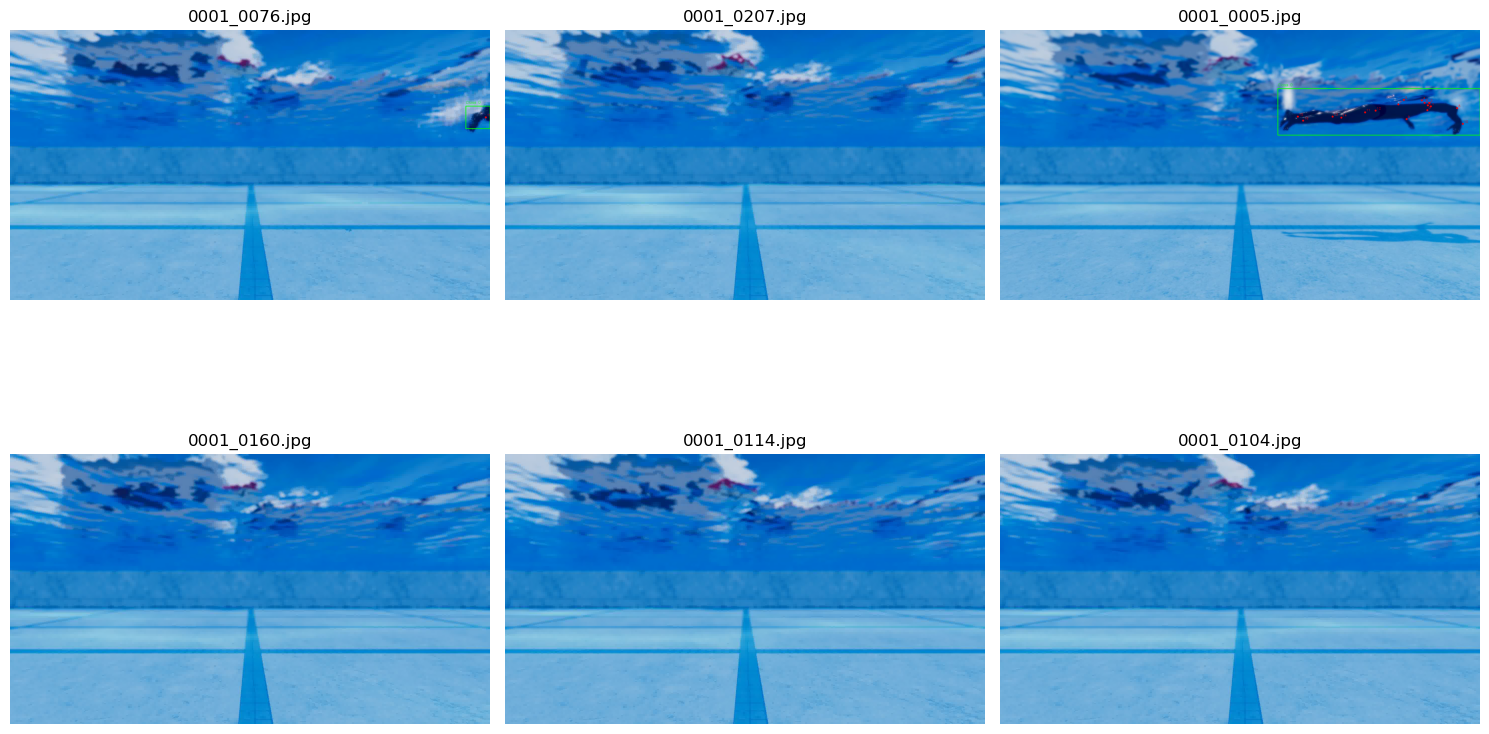

In [33]:
def visualize_annotations(images_dir, labels_dir, num_samples=6, figsize=(15, 10)):
    """
    Visualize YOLO annotations with keypoints and bounding boxes
    
    Args:
        images_dir: Path to directory containing images
        labels_dir: Path to directory containing YOLO format labels
        num_samples: Number of samples to visualize
        figsize: Figure size for matplotlib
    """
    
    # Get list of image files
    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Randomly select images to visualize
    selected_images = random.sample(image_files, min(num_samples, len(image_files)))
    
    # Set up the plot
    cols = 3
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    
    for idx, img_file in enumerate(selected_images):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col] if rows > 1 else axes[col]
        
        img_path = os.path.join(images_dir, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        label_file = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(labels_dir, label_file)
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                lines = f.readlines()
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                
                class_id = int(parts[0])
                
                # Parse bounding box (YOLO format: center_x, center_y, width, height)
                if len(parts) >= 5:
                    x_center, y_center, width, height = map(float, parts[1:5])
                    
                    # Convert to pixel coordinates
                    x_center *= w
                    y_center *= h
                    width *= w
                    height *= h
                    
                    # Convert to top-left corner format
                    x1 = int(x_center - width/2)
                    y1 = int(y_center - height/2)
                    x2 = int(x_center + width/2)
                    y2 = int(y_center + height/2)
                    
                    # Draw bounding box
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    cv2.putText(img, f'Class {class_id}', (x1, y1-10), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
                
                # Parse keypoints if available (assuming 17 keypoints for pose estimation)
                if len(parts) > 5:
                    keypoints_data = list(map(float, parts[5:]))
                    
                    # Assuming format: x1, y1, v1, x2, y2, v2, ... (keypoints are already normalized)
                    keypoints = []
                    for i in range(0, len(keypoints_data), 3):
                        if i + 2 < len(keypoints_data):
                            x, y, visibility = keypoints_data[i], keypoints_data[i+1], keypoints_data[i+2]
                            keypoints.append((x * w, y * h, visibility))
                    
                    # Draw keypoints only (no skeleton connections)
                    for i, (x, y, vis) in enumerate(keypoints):
                        if vis > 0:  # Only draw visible keypoints
                            color = (255, 0, 0) if vis == 2 else (255, 255, 0)  # Red for visible, Yellow for occluded
                            cv2.circle(img, (int(x), int(y)), 4, color, -1)
                            cv2.putText(img, str(i), (int(x)+5, int(y)-5), 
                                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

        
        ax.imshow(img)
        ax.set_title(f'{img_file}')
        ax.axis('off')
    
    # Hide empty subplots
    for idx in range(len(selected_images), rows * cols):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col] if rows > 1 else axes[col]
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Set paths
images_dir = "/Users/artemkiryukhin/Desktop/Code/Projects/SwimHPE/cleaned_Freestyle_part2/images/train"
labels_dir = "/Users/artemkiryukhin/Desktop/Code/Projects/SwimHPE/cleaned_Freestyle_part2/labels/train"

# Visualize some annotations
visualize_annotations(images_dir, labels_dir, num_samples=6)